In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant

In [2]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

## Proportion recalled

In [3]:
n_episode_events = len(atlep1.events)
prop_rec_list = []
for rectype in ('atlep1', 'delayed'):
    for p in participants:
        matches = p.event_matches[rectype]
        prop_rec = len(np.unique(matches)) / n_episode_events
        prop_rec_list.append((f'P{p.sub_n}', rectype, prop_rec))
        
prop_recalled_df = pd.DataFrame(prop_rec_list, columns=('Participant', 'Session', 'Proportion recalled'))

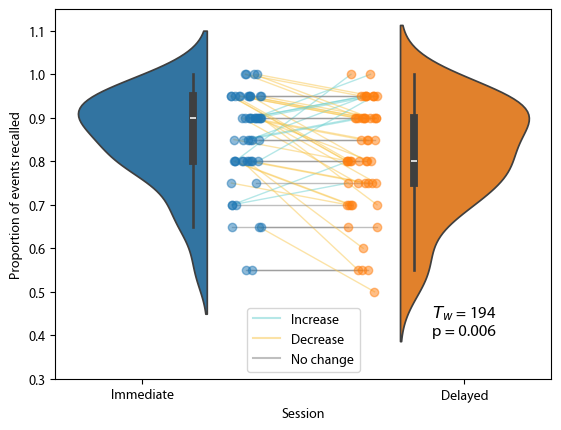

In [4]:
ax = sns.violinplot(prop_recalled_df, 
                    x='Session', 
                    y='Proportion recalled', 
                    hue='Session', split=True, gap=0.5)

inner_boxplot_xshift = 0.03
for line in ax.lines:
    xdata = line.get_xdata()
    center = np.mean(xdata)
    direction = -1 if center < 0.5 else 1  # left vs right violin
    line.set_xdata([x + direction * inner_boxplot_xshift for x in xdata])


imm_props = prop_recalled_df.query('Session == "atlep1"')['Proportion recalled']
del_props = prop_recalled_df.query('Session == "delayed"')['Proportion recalled']

imm_x_offset = 0.32
del_x_offset = -0.32
decrease_color = '#f9c74f'
increase_color = '#6cd0d0'
no_change_color = 'grey'

x_jitter = np.random.uniform(-0.05, 0.05, size=len(participants))

ax.scatter(np.zeros(len(imm_props)) + imm_x_offset + x_jitter, 
           imm_props, 
#            c=plt.cm.tab10(np.linspace(0, 1, len(imm_props), endpoint=True)), 
           color=plt.cm.tab10(0), 
           alpha=0.5,
           zorder=2)
ax.scatter(np.ones(len(del_props)) + del_x_offset + x_jitter, 
           del_props, 
#            c=plt.cm.tab10(np.linspace(0, 1, len(del_props), endpoint=True)), 
           color=plt.cm.tab10(1), 
           alpha=0.5,
           zorder=2)

ax.plot([np.zeros(len(imm_props)) + imm_x_offset + x_jitter, np.ones(len(del_props)) + del_x_offset + x_jitter], 
        [imm_props, del_props], 
        c=no_change_color, 
        alpha=0.5,
        lw=1,
        zorder=1)

for connection_line in ax.get_lines()[-len(participants):]:
    y_imm, y_del = connection_line.get_ydata()
    if y_imm > y_del:
        connection_line.set_color(decrease_color)
    elif y_imm < y_del:
        connection_line.set_color(increase_color)

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(('Immediate', 'Delayed'))
ax.set_ylabel('Proportion of events recalled')
ax.set_ylim(0.3, 1.15)

ax.legend((Line2D([0], [0], color=increase_color, alpha=0.5), 
           Line2D([0], [0], color=decrease_color, alpha=0.5), 
           Line2D([0], [0], color=no_change_color, alpha=0.5)), 
          ('Increase', 'Decrease', 'No change'), loc=8)

w, p = wilcoxon(imm_props, del_props)
ax.text(0.9, 0.4, f'$T_w$ = {w:.3g}\np = {p:.3f}', fontsize='large')

plt.show()

## Number of recall events

In [5]:
n_recall_events = {}
for rectype in ('atlep1', 'delayed'):
    n_ev = []
    for p in participants:
        n_ev.append(len(p.events[rectype]))
    n_recall_events[rectype] = n_ev
    
n_increases = sum(1 for i, j in zip(n_recall_events['atlep1'], n_recall_events['delayed']) if i < j)
n_decreases = sum(1 for i, j in zip(n_recall_events['atlep1'], n_recall_events['delayed']) if i > j)
n_no_change = len(participants) - n_increases - n_decreases

print(f'avg n immediate recall events: {np.mean(n_recall_events['atlep1'])}')
print(f'avg n delayed recall events: {np.mean(n_recall_events['delayed'])}')
print(f'number of increases: {n_increases}')
print(f'number of decreases: {n_decreases}')
print(f'number of no change: {n_no_change}')
print(wilcoxon(n_recall_events['atlep1'], n_recall_events['delayed']))

avg n immediate recall events: 18.245283018867923
avg n delayed recall events: 17.169811320754718
number of increases: 16
number of decreases: 33
number of no change: 4
WilcoxonResult(statistic=np.float64(321.5), pvalue=np.float64(0.003559012499377892))


## Serial position curve

In [6]:
spc_df = pd.DataFrame(columns=('Participant', 'Session', 'Event number', 'Recalled'))
row_ix = 0
for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recalled_events = np.unique(p.event_matches[rectype])
        for episode_event_ix in range(len(atlep1.events)):
            spc_df.loc[row_ix] = (f'P{p.sub_n}', 
                                  rectype, 
                                  episode_event_ix, 
                                  int(episode_event_ix in recalled_events))
            row_ix += 1
            
spc_df['Session'] = spc_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

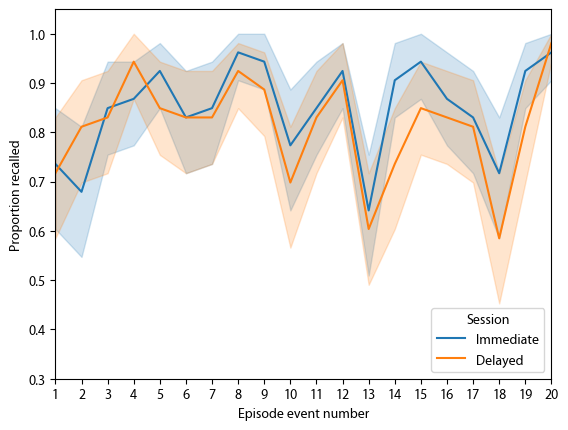

In [7]:
ax = sns.lineplot(spc_df, x='Event number', y='Recalled', hue='Session')
ax.set_xlim(0, len(atlep1.events) - 1)
ax.set_ylim(0.3, 1.05)
ax.set_xticks(list(range(len(atlep1.events))))
ax.set_xticklabels(list(range(1, len(atlep1.events) + 1)))
ax.set_xlabel('Episode event number')
ax.set_ylabel('Proportion recalled')
ax.get_legend().set_loc(4)
plt.show()

## Probability of first recall

In [8]:
pfr_df =  pd.DataFrame(columns=('Participant', 'Session', 'Event number', 'First recall'))
pfr_df[['Participant', 'Session', 'Event number']] = spc_df[['Participant', 'Session', 'Event number']]
pfr_df['First recall'] = 0

for rectype in ('atlep1', 'delayed'):
    ses_name = 'Immediate' if rectype == 'atlep1' else 'Delayed'
    for p in participants:
        first_rec = p.event_matches[rectype][0]
        pfr_df.loc[
            (pfr_df['Participant'] == f'P{p.sub_n}') & 
            (pfr_df['Session'] == ses_name) & 
            (pfr_df['Event number'] == first_rec), 
            'First recall'
        ] = 1

pfr_df['Session'] = pfr_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

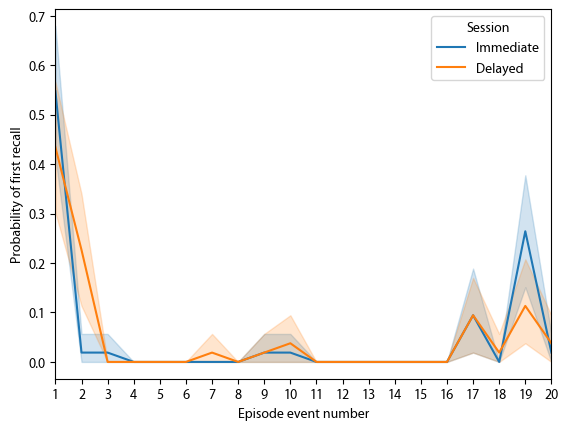

In [9]:
ax = sns.lineplot(pfr_df, x='Event number', y='First recall', hue='Session')
ax.set_xlim(0, len(atlep1.events) - 1)
# ax.set_ylim(0, 1)
ax.set_xticks(list(range(len(atlep1.events))))
ax.set_xticklabels(list(range(1, len(atlep1.events) + 1)))
ax.set_xlabel('Episode event number')
ax.set_ylabel('Probability of first recall')
plt.show()

## Lag-conditional response probability

In [10]:
def lagcrp_counts(recalls, n_items):
    """
    Accumulate actual and possible lag counts for one recall event sequence.
    """
    off = n_items - 1
    actual = np.zeros(2 * n_items - 1)
    possible = np.zeros(2 * n_items - 1)

    recalled = np.zeros(n_items, dtype=bool)
    recalled[recalls[0]] = True

    for k in range(1, len(recalls)):
        from_sp = recalls[k - 1]
        to_sp = recalls[k]

        # Only count a transition to an event not yet recalled.
        if not recalled[to_sp]:
            available = np.flatnonzero(~recalled)
            actual[to_sp - from_sp + off] += 1
            possible[available - from_sp + off] += 1

        recalled[to_sp] = True

    return actual, possible


n_episode_events = len(atlep1.events)
lags = np.arange(-n_episode_events + 1, n_episode_events)
n_lags = lags.shape[0]

lagcrp_df = pd.DataFrame(columns=('Participant', 'Session', 'lag', 'crp'),
                         index=range(len(participants) * 2 * len(lags)))
df_start_ix = 0

for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recalled_events = np.asarray(p.event_matches[rectype])
        actual, possible = lagcrp_counts(recalled_events, n_episode_events)

        with np.errstate(divide='ignore', invalid='ignore'):
            crp = actual / possible
        crp[possible == 0] = np.nan

        lagcrp_df.loc[
            df_start_ix : df_start_ix + n_lags - 1,
            ('Participant', 'Session')
        ] = (f'P{p.sub_n}', rectype)
        lagcrp_df.loc[df_start_ix : df_start_ix + n_lags - 1, 'lag'] = lags
        lagcrp_df.loc[df_start_ix : df_start_ix + n_lags - 1, 'crp'] = crp
        
        df_start_ix += n_lags
        
lagcrp_df['Session'] = lagcrp_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

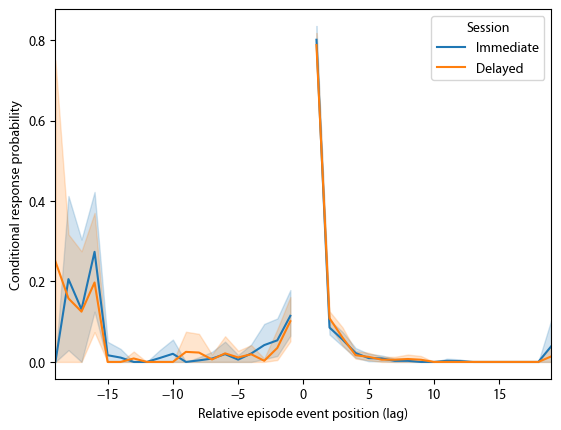

In [11]:
ax = sns.lineplot(lagcrp_df.loc[lagcrp_df['lag'] < 0], 
                  x='lag', 
                  y='crp', 
                  hue='Session')
sns.lineplot(lagcrp_df.loc[lagcrp_df['lag'] > 0], 
             x='lag', 
             y='crp',
             hue='Session', 
             legend=False,
             ax=ax)
ax.set_xlim(lags[0], lags[-1])
ax.set_xlabel('Relative episode event position (lag)')
ax.set_ylabel('Conditional response probability')
plt.show()